## import

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


# new train (fixed autcorr)

/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch 0


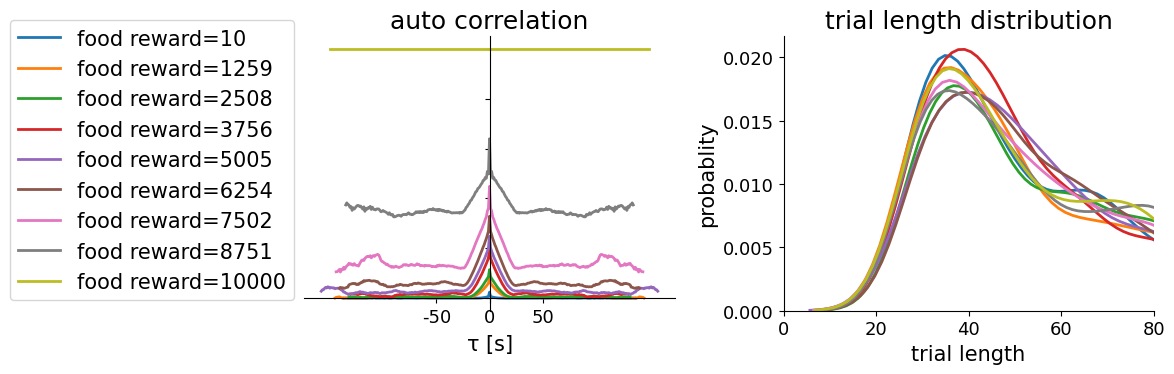

epoch 1


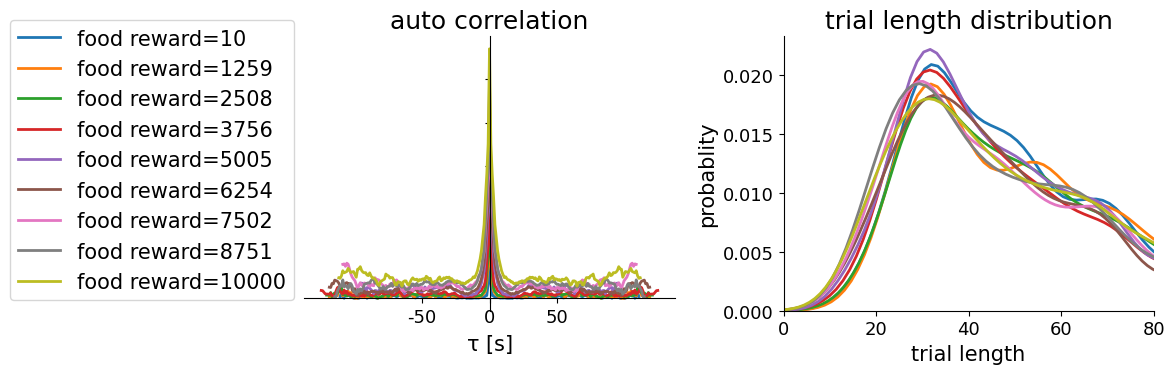

epoch 2


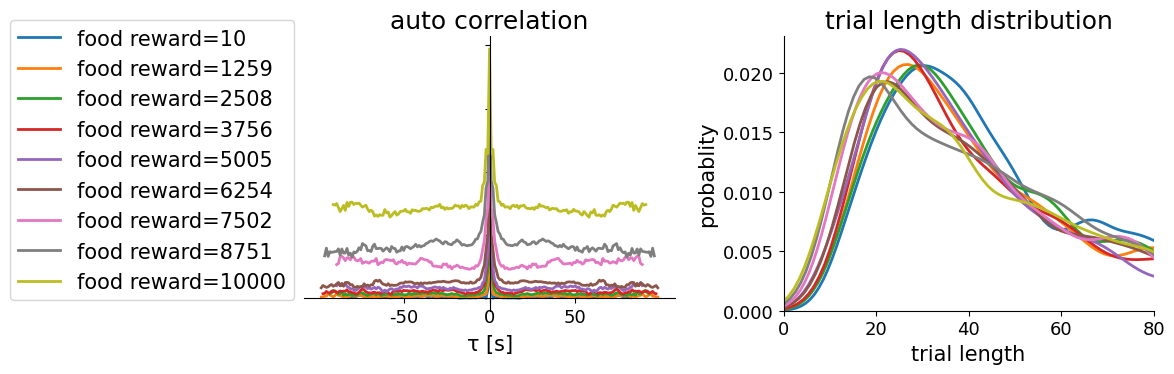

epoch 3


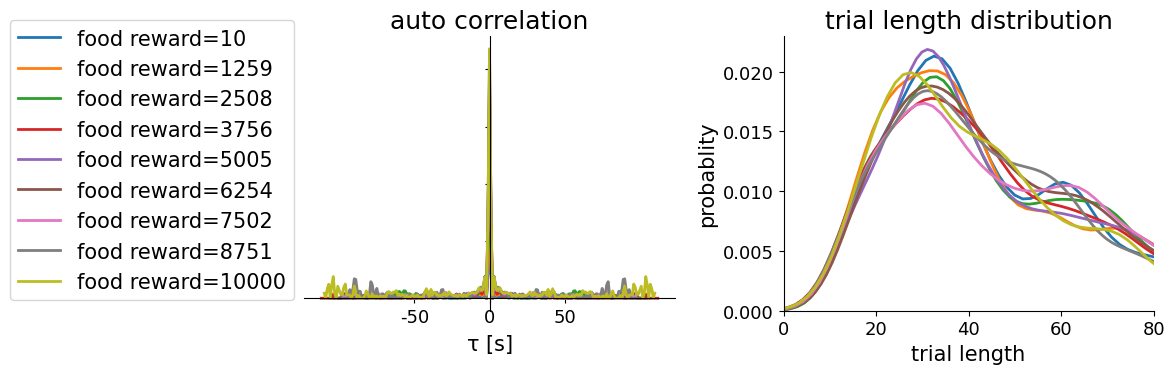

epoch 4


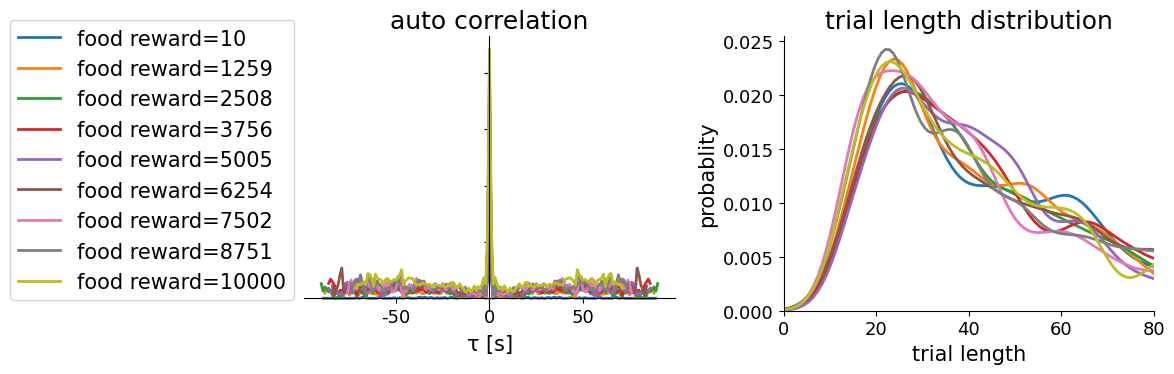

epoch 5


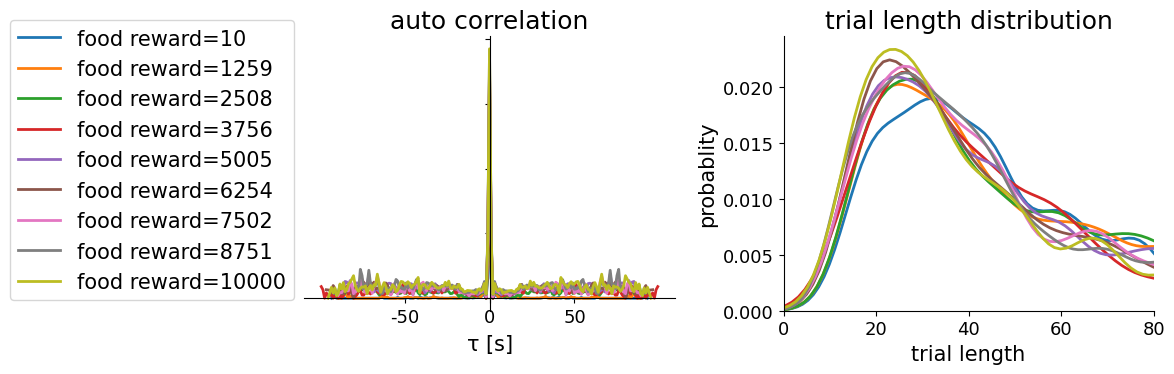

epoch 6


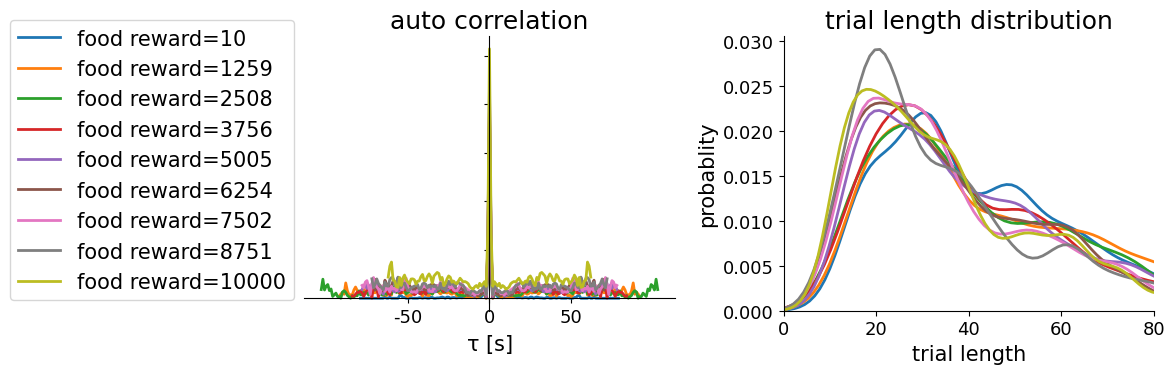

epoch 7


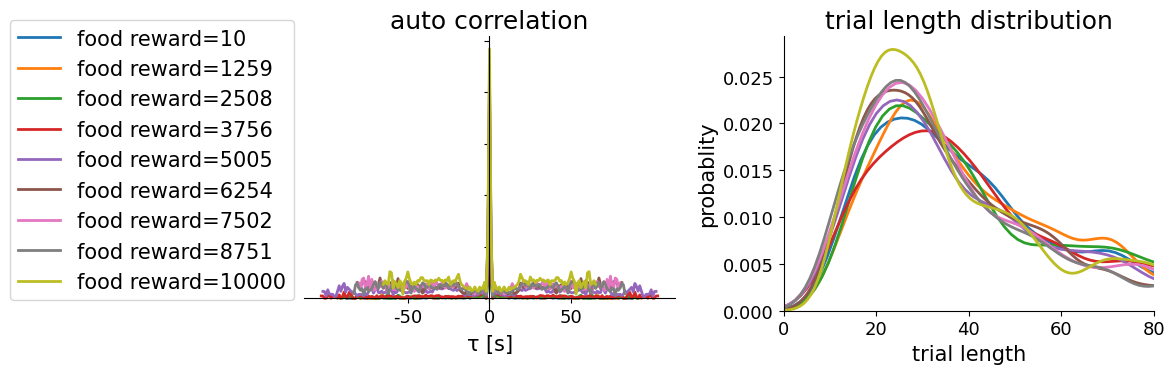

epoch 8


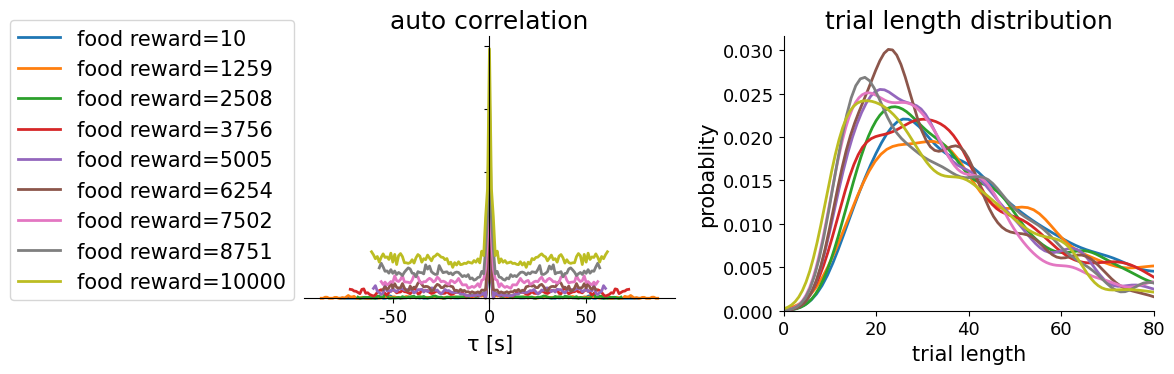

epoch 9


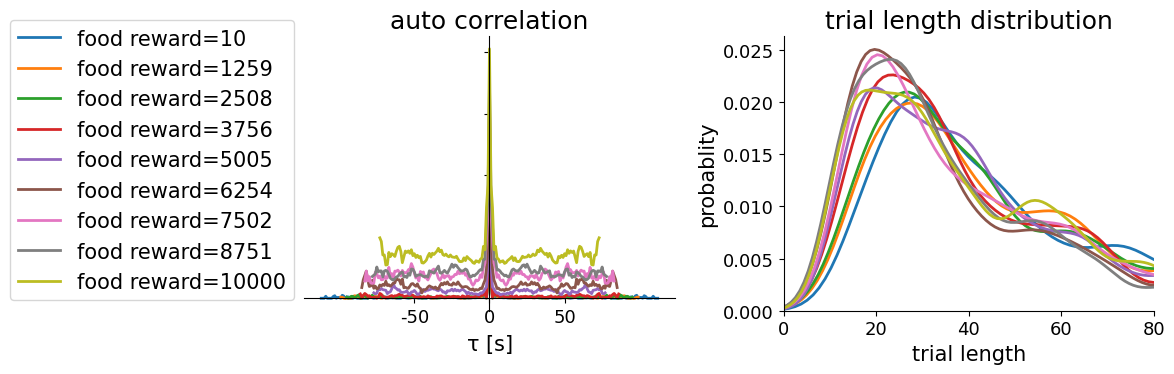

epoch 10


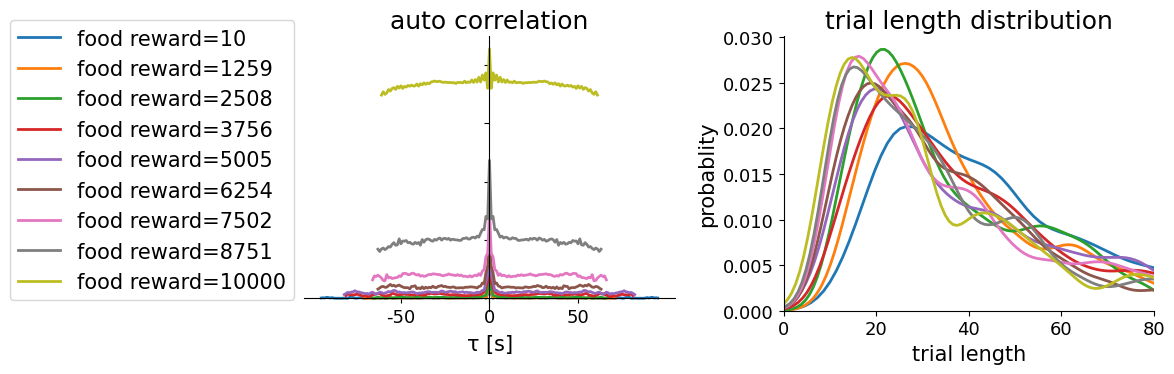

epoch 11


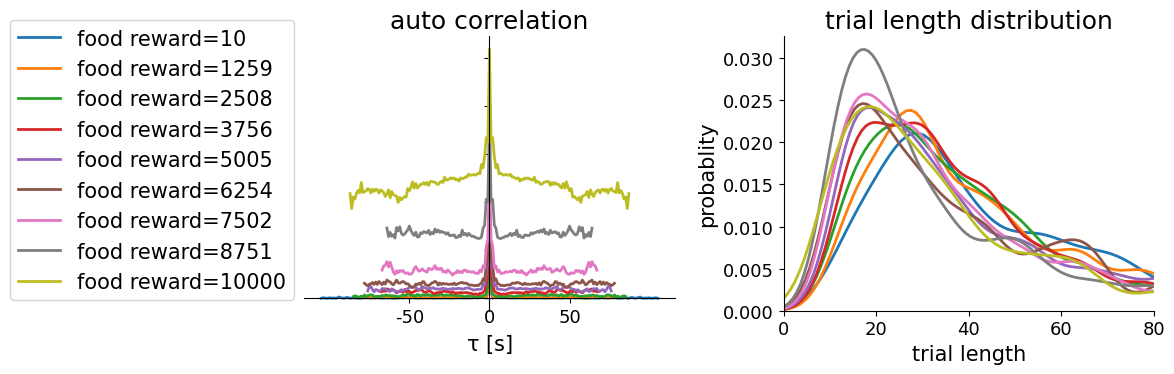

epoch 12


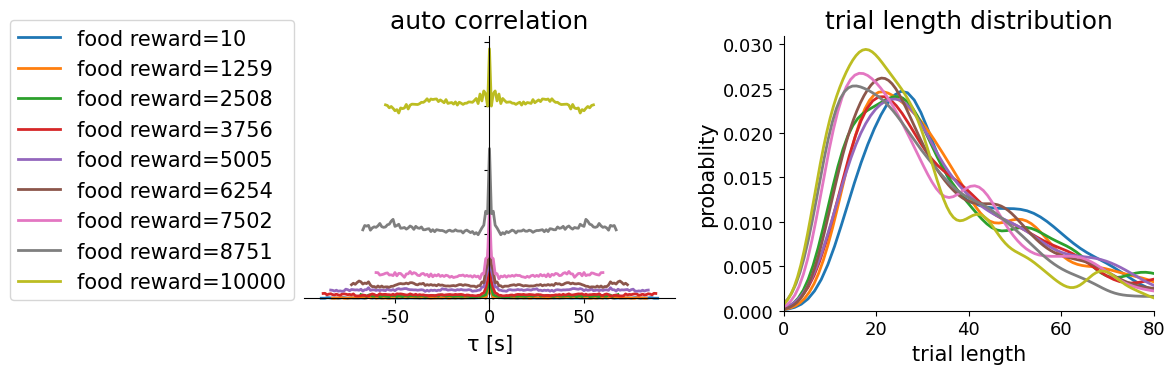

epoch 13


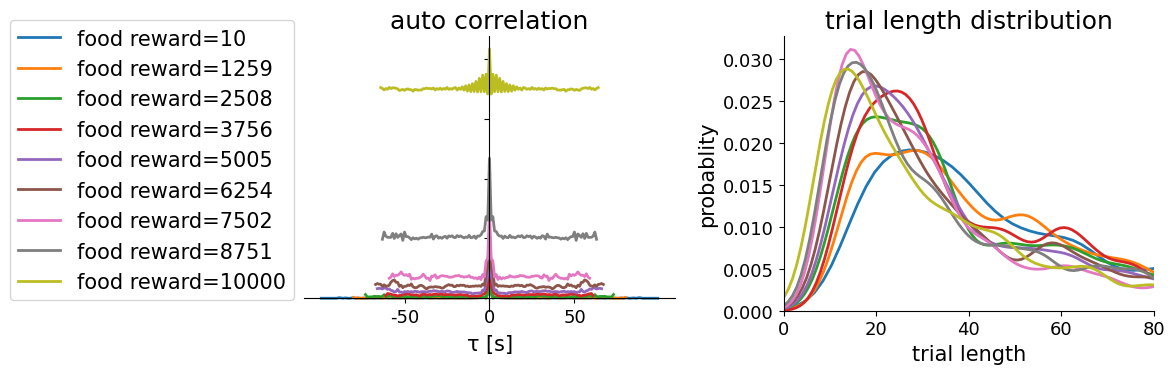

epoch 14


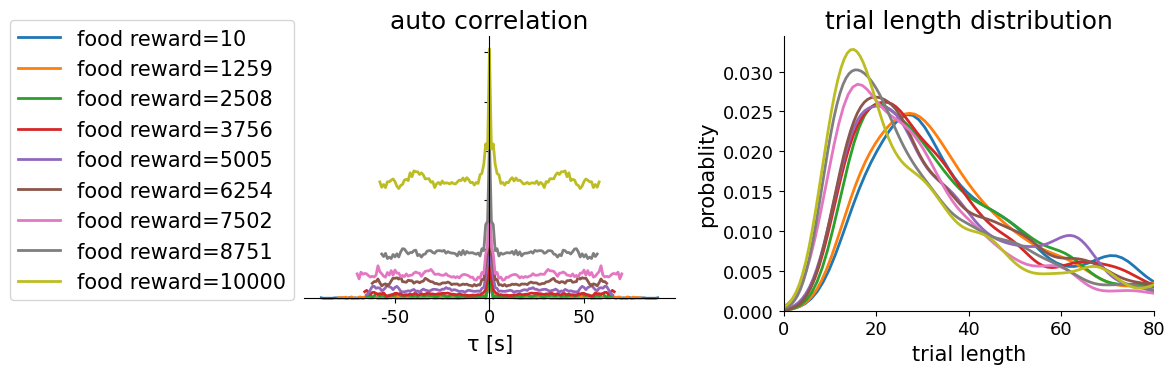

epoch 15


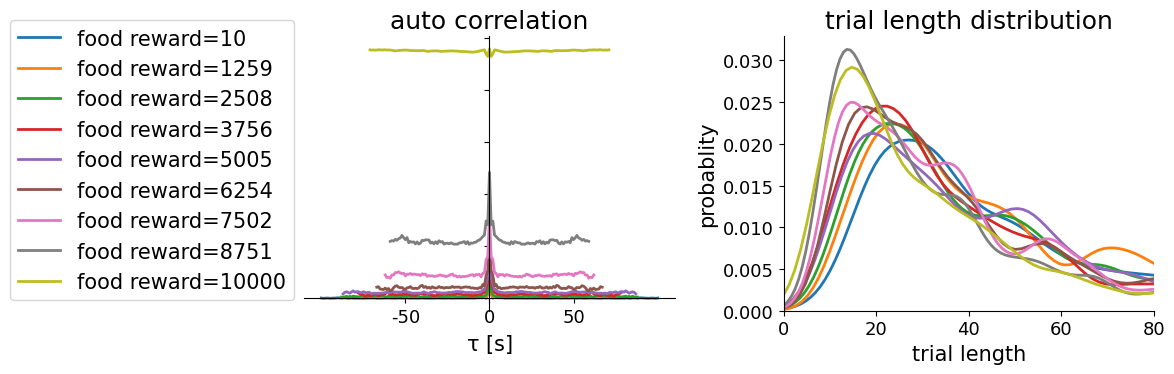

epoch 16


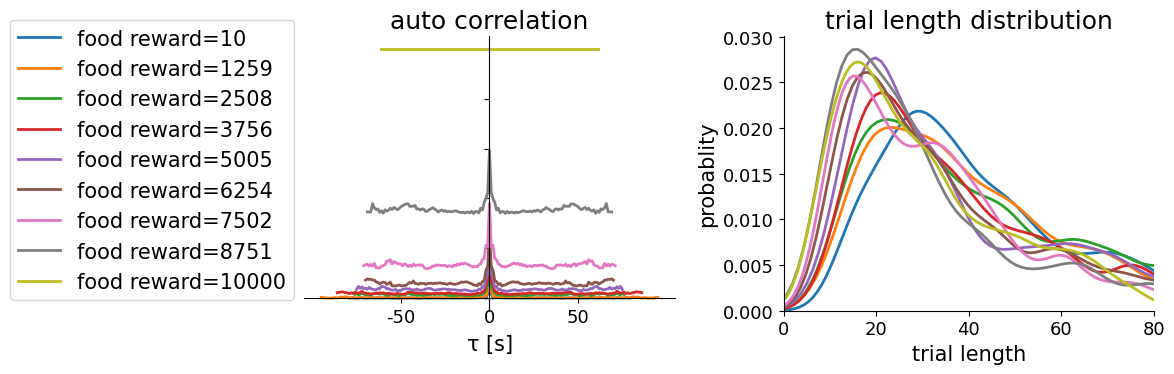

epoch 17


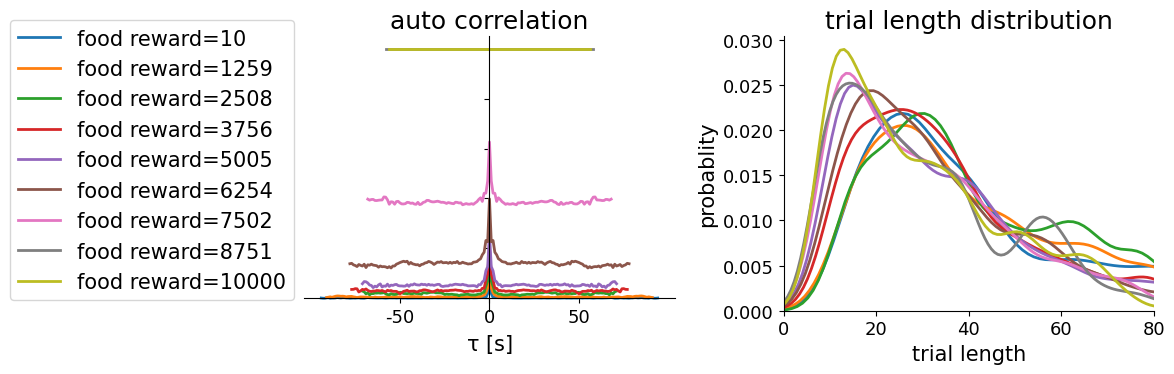

epoch 18


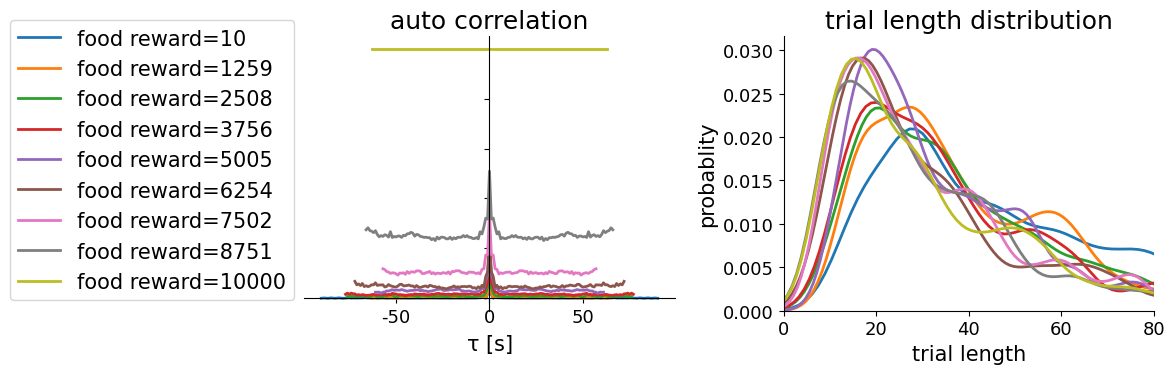

epoch 19


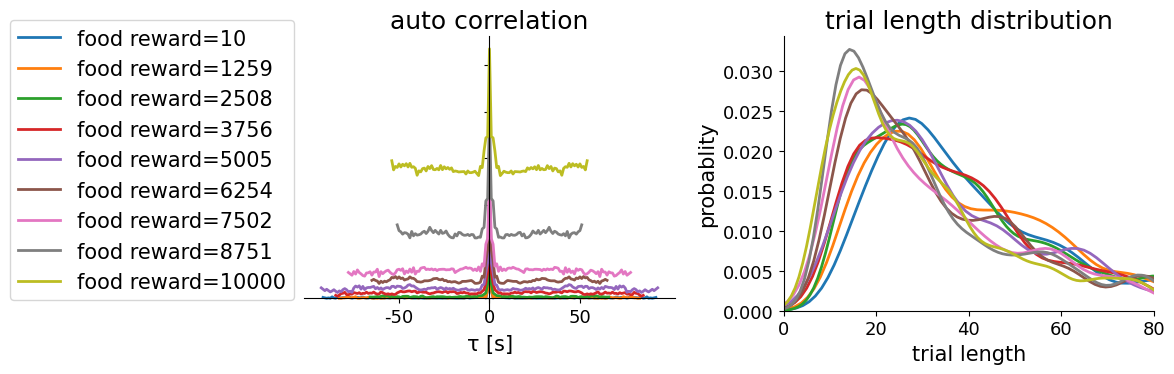

epoch 20


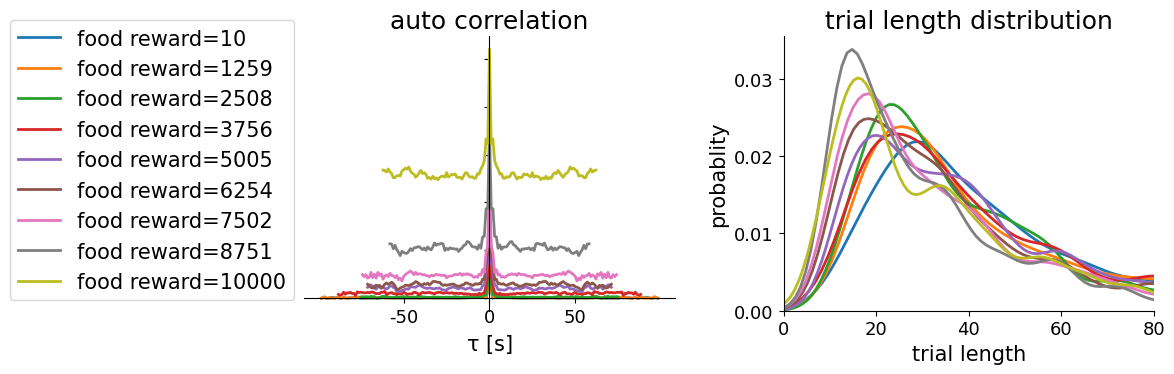

epoch 21


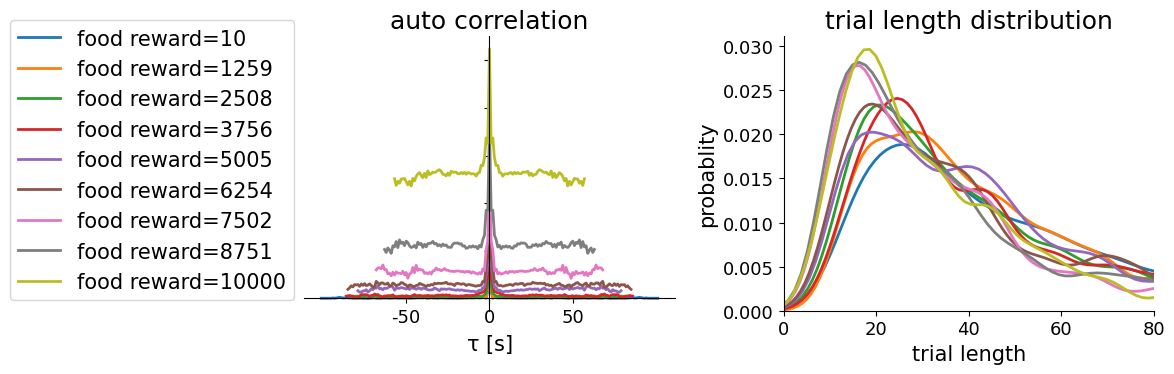

epoch 22


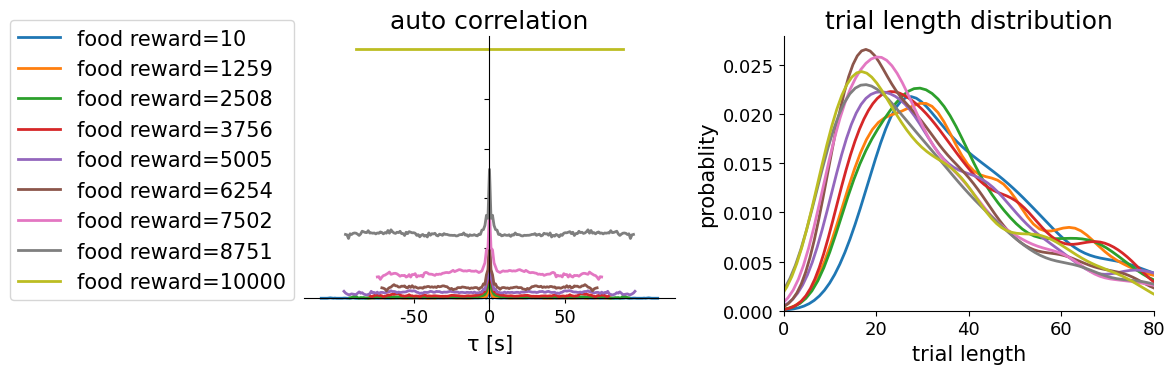

epoch 23


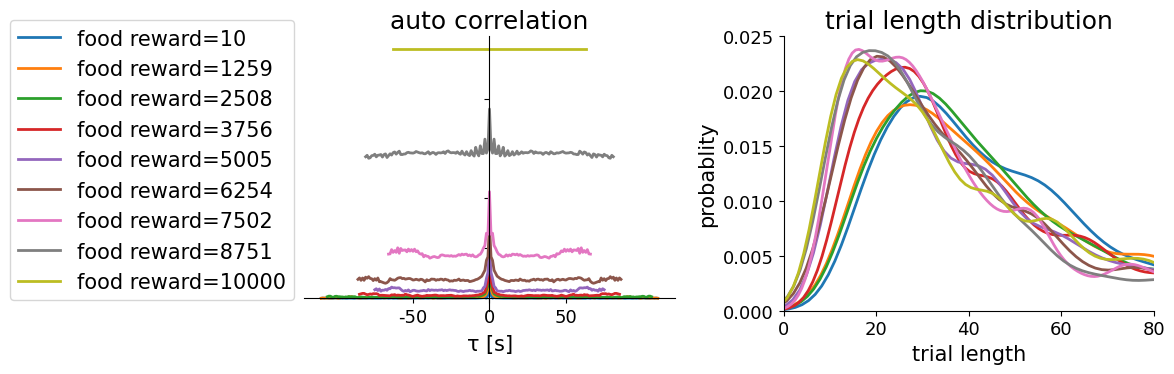

epoch 24


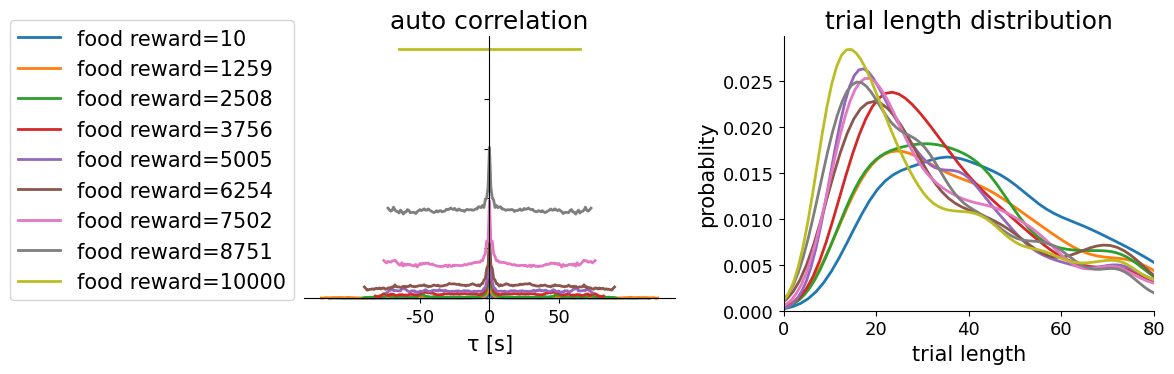

epoch 25


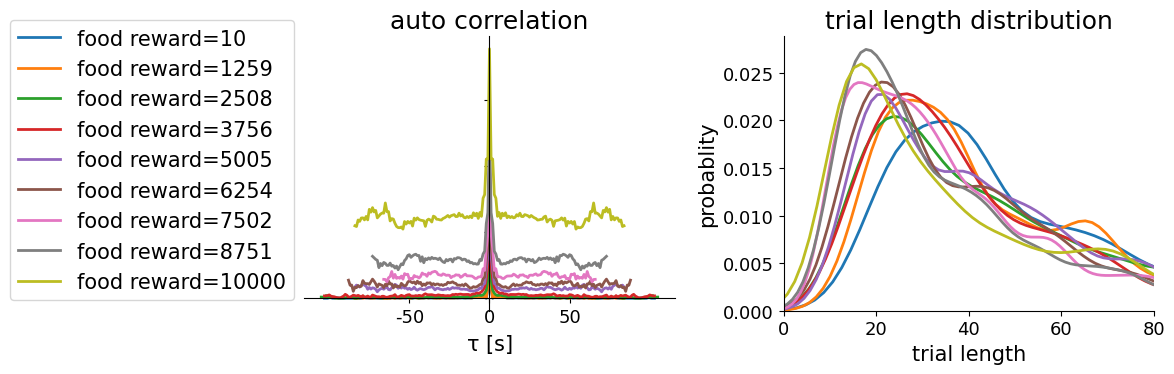

epoch 26


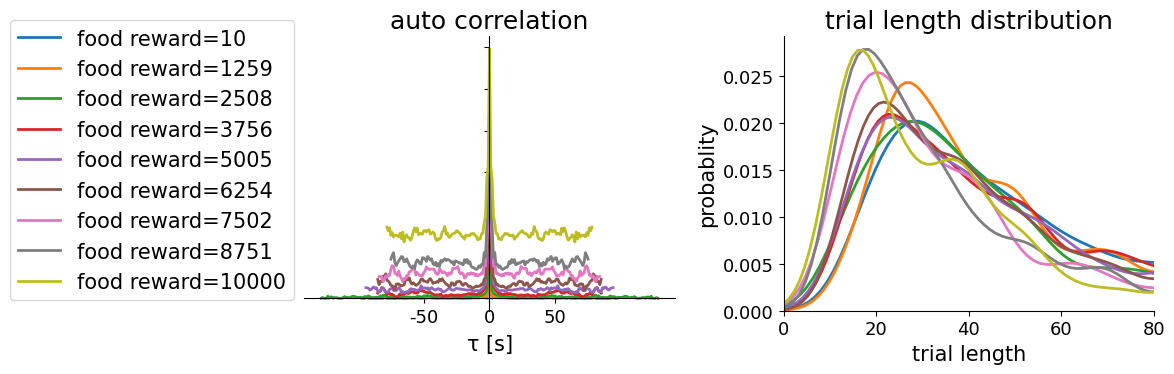

KeyboardInterrupt: 

In [14]:
modelname = 'varyreward67noperoid'
epoch_size = 33333
n_epoch = 55
n_seed = 1
seed = 0
no_episodes = 3333  # for eval plot during training
plot_no_episodes = 333
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 9)
attcost = -1.6
facost = -50
p1p2 = np.array([.6, .7])
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)


task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]}})
task.food_reward_list = food_reward_list
taskbelief = FuncBeliefModel(env=task, rng=1)
task.obs_certainity_possible = p1p2
model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
            clip_range=0.1, ent_coef=0.01, tensorboard_log=f"runs/{modelname}")

# train
for iepoch in range(0,n_epoch):
    thismodel = f'seed{seed}_{modelname}_{iepoch}'
    model.learn(total_timesteps=epoch_size,
                tb_log_name=thismodel,
                reset_num_timesteps=False,)
    model.save(f'ycstore/{thismodel}')
    print('epoch', iepoch)

    # eval
    def eval_wrapper(a):
        episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                num_steps=100000, deterministic=True)
        return episode

    with multiprocess.Pool(processes=8) as pool:
        all_episode_data = pool.map(eval_wrapper, range(no_episodes))


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    # auto correlation 
    for food_reward_idx in range(len(food_reward_list)):
        att_seq_list = []
        for episode in all_episode_data:
            if episode['trial_food_reward_idx'] == food_reward_idx:
                att_seq_list.append([float(elt[1])
                                    for elt in episode['actions']])
        # Sorting based on increasing trial length
        sorted_list_of_lists = sorted(att_seq_list, key=len)
        # Choosing what range of trial lengths to use. Could modify to be more consistent.
        sequences = sorted_list_of_lists[-plot_no_episodes:]
        # autocorr
        autocorr, total_counts = empirical_autocorrelation(
            sequences, min_no_samples=1111)
        xs = np.arange(0, len(autocorr), 1)
        xs = xs-len(xs)//2
        ax1.plot(xs, autocorr,
                    label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
        # trial len dist
        sns.kdeplot([len(a) for a in att_seq_list],
                    fill=False, bw_adjust=0.5, ax=ax2)

        ax1.set_xlabel(r'$\tau$ [s]')
        ax1.set_title('auto correlation')
        # ax1.set_xlim(-50,50)
        # ax1.set_ylim(0, .03)
        ax1.set_xticks([-50, 0, 50])
        ax1.set_yticklabels([])
        centerax(ax1)
        quickleg(ax1)
        ax2.set_xlabel('trial length')
        ax2.set_ylabel('probablity')
        ax2.set_xlim(0, 80)
        ax2.set_title('trial length distribution')

    plt.tight_layout()
    quicksave('autocorr', modelname)
    plt.show()

notify(f'training {thismodel} finished')


epoch 24 model seed0_varyreward67noperoid_24


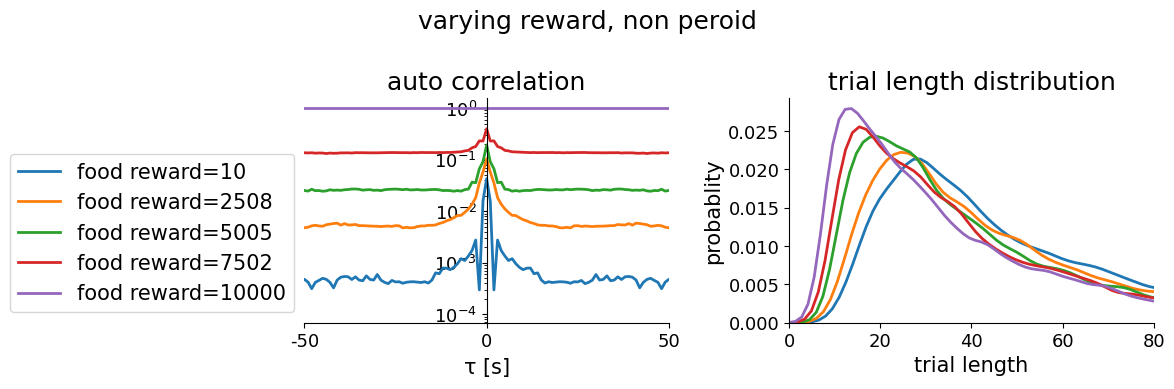

In [30]:
# eval plot
iepoch=24

modelname = 'varyreward67noperoid'
epoch_size = 33333
n_epoch = 55
n_seed = 1
seed = 0
no_episodes = 33333# for eval plot during training
plot_no_episodes = 33333
vmin, vmax = 10, 10000
food_reward_list = np.linspace(vmin, vmax, 5)
attcost = -1.6
facost = -50
p1p2 = np.array([.6, .7])
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)


task = AFR2(spec={'agent': {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]}})
task.food_reward_list = food_reward_list
taskbelief = FuncBeliefModel(env=task, rng=1)
task.obs_certainity_possible = p1p2

thismodel = f'seed{seed}_{modelname}_{iepoch}'
model=PPO.load(f'ycstore/{thismodel}')
print('epoch', iepoch,f'model', thismodel)

# eval
def eval_wrapper(a):
    episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                            num_steps=100000, deterministic=True)
    return episode

with multiprocess.Pool(processes=8) as pool:
    all_episode_data = pool.map(eval_wrapper, range(no_episodes))


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# auto correlation 
for food_reward_idx in range(len(food_reward_list)):
    att_seq_list = []
    for episode in all_episode_data:
        if episode['trial_food_reward_idx'] == food_reward_idx:
            att_seq_list.append([float(elt[1])
                                for elt in episode['actions']])
    # Sorting based on increasing trial length
    sorted_list_of_lists = sorted(att_seq_list, key=len)
    # Choosing what range of trial lengths to use. Could modify to be more consistent.
    sequences = sorted_list_of_lists[-plot_no_episodes:]
    # autocorr
    autocorr, total_counts = empirical_autocorrelation(
        sequences, min_no_samples=0)
    xs = np.arange(0, len(autocorr), 1)
    xs = xs-len(xs)//2
    ax1.plot(xs, autocorr,
                label=f'food reward={food_reward_list[food_reward_idx]:.0f}')
    # trial len dist
    sns.kdeplot([len(a) for a in att_seq_list],
                fill=False, bw_adjust=0.5, ax=ax2)

    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    ax1.set_xlim(-50,50)
    # ax1.set_ylim(0, .03)
    ax1.set_xticks([-50, 0, 50])
    ax1.set_yticklabels([])
    ax1.set_yscale('log')
    # centerax(ax1)
    ax1.spines['left'].set_position('zero')
    quickleg(ax1)
    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_xlim(0, 80)
    ax2.set_title('trial length distribution')

fig.suptitle('varying reward, non peroid')
plt.tight_layout()
quicksave('autocorr', modelname)
plt.show()

